In [4]:
import os

print(os.listdir("/content"))

['.config', 'credit_card_fraud_2026.csv', 'sample_data']


In [5]:
import pandas as pd

df = pd.read_csv("/content/credit_card_fraud_2026.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (20000, 26)


,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [7]:
print("All columns in the dataset:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

All columns in the dataset:
['transaction_id', 'amount_usd', 'merchant_category', 'card_type', 'auth_method', 'channel', 'device_type', 'is_foreign_transaction', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'is_ai_generated_scam_attempt', 'merchant_risk_score', 'prior_disputes', 'is_fraud']

Data types:
transaction_id                    int64
amount_usd                      float64
merchant_category                object
card_type                        object
auth_method                      object
channel                          object
device_type                      object
is_foreign_transaction             bool
hours_since_last_txn            float64
txn_count_last_24h                int64
distance_from_home_km           float64
card_age_months 

In [8]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check fraud distribution
print("\nFraud distribution:")
print(df["is_fraud"].value_counts())

# Check fraud percentage
fraud_percentage = df["is_fraud"].mean() * 100
print(f"\nFraud percentage: {fraud_percentage:.2f}%")

Missing values in each column:
transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

Fraud distribution:
is_fraud
0    19661
1      339
Name: count, dtype: 

In [9]:
# Separate features and target

X = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (20000, 25)
Target: (20000,)


In [10]:
X = X.drop("transaction_id", axis=1)

print("Transaction ID removed.")
print("Remaining features:", X.shape[1])

Transaction ID removed.
Remaining features: 24


In [11]:
# Numerical columns
numeric_features = [
    "amount_usd",
    "hours_since_last_txn",
    "txn_count_last_24h",
    "distance_from_home_km",
    "card_age_months",
    "customer_age",
    "account_balance_usd",
    "cvv_retry_count",
    "velocity_score",
    "time_of_day_hour",
    "day_of_week",
    "merchant_risk_score",
    "prior_disputes"
]

# Categorical columns
categorical_features = [
    "merchant_category",
    "card_type",
    "auth_method",
    "channel",
    "device_type"
]

# Boolean columns
boolean_features = [
    "is_foreign_transaction",
    "is_new_merchant",
    "used_vpn",
    "ip_country_mismatch",
    "billing_shipping_mismatch",
    "is_ai_generated_scam_attempt"
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Boolean features:", len(boolean_features))

Numerical features: 13
Categorical features: 5
Boolean features: 6


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nFraud in training data:", y_train.sum())
print("Fraud in testing data:", y_test.sum())

Training samples: 16000
Testing samples: 4000

Fraud in training data: 271
Fraud in testing data: 68


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bool", "passthrough", boolean_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [14]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data processed:", X_train_processed.shape)
print("Testing data processed:", X_test_processed.shape)

Training data processed: (16000, 54)
Testing data processed: (4000, 54)


In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training the Random Forest model...")

model.fit(X_train_processed, y_train)

print("✅ Model training completed!")

Training the Random Forest model...
✅ Model training completed!


In [16]:
y_pred = model.predict(X_test_processed)
y_probability = model.predict_proba(X_test_processed)[:, 1]

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 4000


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("===== MODEL PERFORMANCE =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred, zero_division=0))

===== MODEL PERFORMANCE =====
Accuracy : 0.9830
Precision: 0.5000
Recall   : 0.0294
F1 Score : 0.0556

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3932
           1       0.50      0.03      0.06        68

    accuracy                           0.98      4000
   macro avg       0.74      0.51      0.52      4000
weighted avg       0.98      0.98      0.98      4000



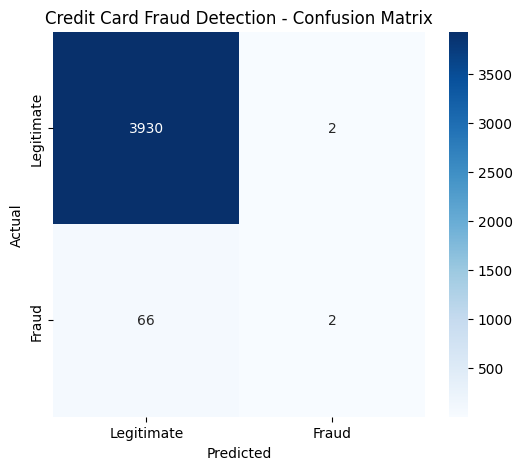

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Credit Card Fraud Detection - Confusion Matrix")

plt.show()

In [19]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.51, 0.05)

results = []

for threshold in thresholds:
    predictions = (y_probability >= threshold).astype(int)

    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

print(results_df.round(3))

   Threshold  Precision  Recall  F1 Score
0       0.05      0.034   0.985     0.066
1       0.10      0.061   0.926     0.114
2       0.15      0.092   0.779     0.165
3       0.20      0.111   0.515     0.183
4       0.25      0.154   0.368     0.217
5       0.30      0.174   0.235     0.200
6       0.35      0.232   0.191     0.210
7       0.40      0.214   0.088     0.125
8       0.45      0.333   0.059     0.100
9       0.50      0.500   0.029     0.056


In [20]:
best_row = results_df.loc[results_df["F1 Score"].idxmax()]

print("===== BEST THRESHOLD =====")
print(f"Threshold: {best_row['Threshold']:.2f}")
print(f"Precision: {best_row['Precision']:.3f}")
print(f"Recall:    {best_row['Recall']:.3f}")
print(f"F1 Score:  {best_row['F1 Score']:.3f}")

===== BEST THRESHOLD =====
Threshold: 0.25
Precision: 0.154
Recall:    0.368
F1 Score:  0.217


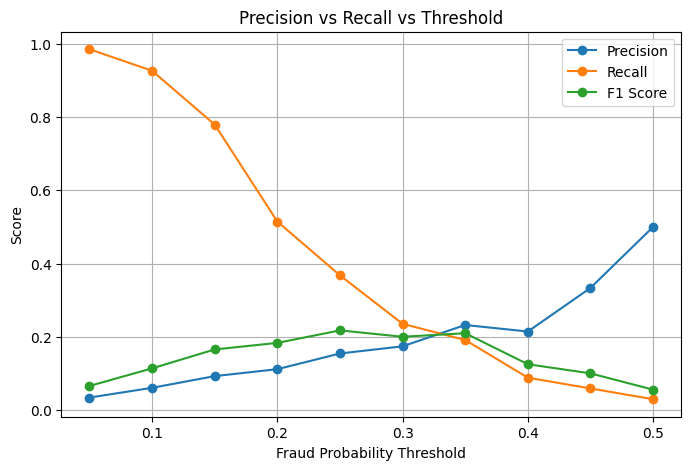

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Threshold"],
    results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    results_df["Threshold"],
    results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    results_df["Threshold"],
    results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Fraud Probability Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

In [22]:
!pip -q install gradio

In [23]:
import gradio as gr
import numpy as np

BEST_THRESHOLD = 0.25

def predict_transaction(
    amount_usd,
    merchant_category,
    card_type,
    auth_method,
    channel,
    device_type,
    is_foreign_transaction,
    hours_since_last_txn,
    txn_count_last_24h,
    distance_from_home_km,
    card_age_months,
    customer_age,
    account_balance_usd,
    is_new_merchant,
    used_vpn,
    ip_country_mismatch,
    billing_shipping_mismatch,
    cvv_retry_count,
    velocity_score,
    time_of_day_hour,
    day_of_week,
    is_ai_generated_scam_attempt,
    merchant_risk_score,
    prior_disputes
):

    transaction = pd.DataFrame([{
        "amount_usd": amount_usd,
        "merchant_category": merchant_category,
        "card_type": card_type,
        "auth_method": auth_method,
        "channel": channel,
        "device_type": device_type,
        "is_foreign_transaction": is_foreign_transaction,
        "hours_since_last_txn": hours_since_last_txn,
        "txn_count_last_24h": txn_count_last_24h,
        "distance_from_home_km": distance_from_home_km,
        "card_age_months": card_age_months,
        "customer_age": customer_age,
        "account_balance_usd": account_balance_usd,
        "is_new_merchant": is_new_merchant,
        "used_vpn": used_vpn,
        "ip_country_mismatch": ip_country_mismatch,
        "billing_shipping_mismatch": billing_shipping_mismatch,
        "cvv_retry_count": cvv_retry_count,
        "velocity_score": velocity_score,
        "time_of_day_hour": time_of_day_hour,
        "day_of_week": day_of_week,
        "is_ai_generated_scam_attempt": is_ai_generated_scam_attempt,
        "merchant_risk_score": merchant_risk_score,
        "prior_disputes": prior_disputes
    }])

    processed = preprocessor.transform(transaction)

    probability = model.predict_proba(processed)[0][1]

    if probability >= BEST_THRESHOLD:
        result = "🚨 FRAUD / HIGH RISK"
    else:
        result = "✅ TRANSACTION APPEARS SAFE"

    risk_score = probability * 100

    return result, f"{risk_score:.2f}%"

In [24]:
merchant_categories = df["merchant_category"].unique().tolist()
card_types = df["card_type"].unique().tolist()
auth_methods = df["auth_method"].unique().tolist()
channels = df["channel"].unique().tolist()
devices = df["device_type"].unique().tolist()

with gr.Blocks(theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # 🛡️ FRAUDGUARD
    ### AI-Powered Credit Card Fraud Detection
    **Detect suspicious transactions using Machine Learning**
    """)

    with gr.Row():

        with gr.Column():

            amount = gr.Number(
                label="💰 Transaction Amount (USD)",
                value=100
            )

            merchant = gr.Dropdown(
                merchant_categories,
                label="Merchant Category"
            )

            card = gr.Dropdown(
                card_types,
                label="Card Type"
            )

            auth = gr.Dropdown(
                auth_methods,
                label="Authentication Method"
            )

            channel = gr.Dropdown(
                channels,
                label="Channel"
            )

            device = gr.Dropdown(
                devices,
                label="Device Type"
            )

            foreign = gr.Checkbox(
                label="Foreign Transaction"
            )

            new_merchant = gr.Checkbox(
                label="New Merchant"
            )

            vpn = gr.Checkbox(
                label="VPN Used"
            )

            ip_mismatch = gr.Checkbox(
                label="IP Country Mismatch"
            )

            billing_mismatch = gr.Checkbox(
                label="Billing / Shipping Mismatch"
            )

        with gr.Column():

            hours = gr.Number(
                label="Hours Since Last Transaction",
                value=5
            )

            txn_count = gr.Number(
                label="Transactions in Last 24h",
                value=3
            )

            distance = gr.Number(
                label="Distance From Home (km)",
                value=10
            )

            card_age = gr.Number(
                label="Card Age (months)",
                value=24
            )

            age = gr.Number(
                label="Customer Age",
                value=30
            )

            balance = gr.Number(
                label="Account Balance (USD)",
                value=3000
            )

            cvv = gr.Number(
                label="CVV Retry Count",
                value=0
            )

            velocity = gr.Number(
                label="Velocity Score",
                value=20
            )

            time_hour = gr.Number(
                label="Time of Day Hour",
                value=14
            )

            day = gr.Number(
                label="Day of Week",
                value=3
            )

            scam = gr.Checkbox(
                label="AI Generated Scam Attempt"
            )

            merchant_risk = gr.Number(
                label="Merchant Risk Score",
                value=30
            )

            disputes = gr.Number(
                label="Previous Disputes",
                value=0
            )

    analyze = gr.Button(
        "🔍 ANALYZE TRANSACTION",
        variant="primary"
    )

    gr.Markdown("## 📊 AI Detection Result")

    result = gr.Textbox(
        label="Detection Result"
    )

    risk = gr.Textbox(
        label="Fraud Risk Score"
    )

    analyze.click(
        predict_transaction,
        inputs=[
            amount,
            merchant,
            card,
            auth,
            channel,
            device,
            foreign,
            hours,
            txn_count,
            distance,
            card_age,
            age,
            balance,
            new_merchant,
            vpn,
            ip_mismatch,
            billing_mismatch,
            cvv,
            velocity,
            time_hour,
            day,
            scam,
            merchant_risk,
            disputes
        ],
        outputs=[
            result,
            risk
        ]
    )

app.launch(share=True)

/tmp/ipykernel_588/2576081522.py:7: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5caeb801a7d776b936.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [25]:
df.sample(5)

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
7345,7346,23.03,Gift Cards,Visa,3D Secure,Contactless,Android Phone,False,10.50,2,...,False,False,0,16.5,17,5,False,100.0,0,0
596,597,99.99,Gaming,Amex,3D Secure,POS,Mac,False,0.33,3,...,False,False,0,38.7,11,3,False,69.1,0,0
10260,10261,71.61,Restaurants,Mastercard,OTP,Online,iPhone,False,13.60,5,...,False,False,0,12.2,1,0,False,0.0,0,0
14428,14429,31.61,Online Retail,Mastercard,No Authentication,POS,Android Phone,False,2.24,2,...,False,False,0,18.0,19,1,False,25.1,1,0
12080,12081,163.16,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,17.31,3,...,False,False,0,0.0,13,1,False,34.8,1,0


In [26]:
df[df["is_fraud"] == 1].head(5)

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
63,64,2396.82,Crypto Exchange,Visa,OTP,ATM,Mac,False,5.37,3,...,False,False,1,11.3,5,5,False,92.0,0,1
148,149,18.34,Online Retail,Visa,3D Secure,Online,Android Phone,False,8.70,2,...,True,True,0,17.8,4,1,False,18.6,1,1
267,268,7.25,Gaming,Visa,No Authentication,ATM,Tablet,False,4.00,5,...,False,False,1,23.9,16,1,False,67.1,0,1
363,364,246.90,Crypto Exchange,Amex,OTP,POS,POS Terminal,False,5.18,1,...,False,False,2,8.2,12,0,False,85.7,0,1
391,392,576.76,Crypto Exchange,Visa,OTP,Online,POS Terminal,False,4.29,1,...,False,True,0,9.5,20,5,False,78.4,1,1


In [27]:
import gradio as gr
import pandas as pd
import random

# ==========================================
# FRAUDGUARD - ATTRACTIVE ML WEB APP
# ==========================================

BEST_THRESHOLD = 0.25

# Get example transactions
safe_examples = df[df["is_fraud"] == 0]
fraud_examples = df[df["is_fraud"] == 1]


def analyze_transaction(row):

    transaction = pd.DataFrame([{
        "amount_usd": row["amount_usd"],
        "merchant_category": row["merchant_category"],
        "card_type": row["card_type"],
        "auth_method": row["auth_method"],
        "channel": row["channel"],
        "device_type": row["device_type"],
        "is_foreign_transaction": row["is_foreign_transaction"],
        "hours_since_last_txn": row["hours_since_last_txn"],
        "txn_count_last_24h": row["txn_count_last_24h"],
        "distance_from_home_km": row["distance_from_home_km"],
        "card_age_months": row["card_age_months"],
        "customer_age": row["customer_age"],
        "account_balance_usd": row["account_balance_usd"],
        "is_new_merchant": row["is_new_merchant"],
        "used_vpn": row["used_vpn"],
        "ip_country_mismatch": row["ip_country_mismatch"],
        "billing_shipping_mismatch": row["billing_shipping_mismatch"],
        "cvv_retry_count": row["cvv_retry_count"],
        "velocity_score": row["velocity_score"],
        "time_of_day_hour": row["time_of_day_hour"],
        "day_of_week": row["day_of_week"],
        "is_ai_generated_scam_attempt": row["is_ai_generated_scam_attempt"],
        "merchant_risk_score": row["merchant_risk_score"],
        "prior_disputes": row["prior_disputes"]
    }])

    processed = preprocessor.transform(transaction)

    probability = model.predict_proba(processed)[0][1]
    risk = probability * 100

    if probability >= BEST_THRESHOLD:
        result = "🚨 FRAUD / HIGH RISK"
    else:
        result = "✅ TRANSACTION APPEARS SAFE"

    return result, f"{risk:.2f}%", row


# ==========================================
# BUTTON FUNCTIONS
# ==========================================

def test_safe():
    row = safe_examples.sample(1).iloc[0]

    result, risk, data = analyze_transaction(row)

    info = f"""
### 💳 Transaction Details

**Amount:** ${data['amount_usd']:.2f}

**Merchant:** {data['merchant_category']}

**Card:** {data['card_type']}

**Channel:** {data['channel']}

**Device:** {data['device_type']}

**Foreign Transaction:** {data['is_foreign_transaction']}

**Merchant Risk:** {data['merchant_risk_score']}

**Velocity Score:** {data['velocity_score']}
"""

    return result, risk, info


def test_fraud():
    row = fraud_examples.sample(1).iloc[0]

    result, risk, data = analyze_transaction(row)

    info = f"""
### 💳 Transaction Details

**Amount:** ${data['amount_usd']:.2f}

**Merchant:** {data['merchant_category']}

**Card:** {data['card_type']}

**Channel:** {data['channel']}

**Device:** {data['device_type']}

**Foreign Transaction:** {data['is_foreign_transaction']}

**Merchant Risk:** {data['merchant_risk_score']}

**Velocity Score:** {data['velocity_score']}
"""

    return result, risk, info


# ==========================================
# CSS DESIGN
# ==========================================

css = """

body {
    background: linear-gradient(135deg, #0f172a, #111827, #172554);
}

.gradio-container {
    max-width: 1100px !important;
}

#title {
    text-align: center;
    padding: 25px;
}

#title h1 {
    font-size: 42px;
    font-weight: 800;
}

#subtitle {
    text-align: center;
    font-size: 18px;
    color: #94a3b8;
}

button {
    border-radius: 12px !important;
    font-weight: 700 !important;
}

#safe-btn {
    background: #16a34a !important;
    color: white !important;
}

#fraud-btn {
    background: #dc2626 !important;
    color: white !important;
}

#analyze {
    background: #2563eb !important;
    color: white !important;
    font-size: 18px !important;
}

"""

# ==========================================
# BUILD APP
# ==========================================

with gr.Blocks(css=css, title="FraudGuard AI") as app:

    gr.Markdown(
        """
        <div id="title">
        <h1>🛡️ FRAUDGUARD</h1>
        <p id="subtitle">
        AI-Powered Credit Card Fraud Detection System
        </p>
        </div>
        """,
        elem_id="title"
    )

    gr.Markdown(
        """
        ### 🤖 Machine Learning Command Center

        **Random Forest Classifier** • **20,000 Kaggle Transactions**
        • **1.70% Fraud Rate** • **Optimized Threshold: 25%**
        """
    )

    # Dataset statistics
    with gr.Row():

        with gr.Column():
            gr.Markdown(
                f"""
                ### 📊 DATASET
                **20,000** transactions
                """
            )

        with gr.Column():
            gr.Markdown(
                f"""
                ### 🚨 FRAUD CASES
                **339** detected in dataset
                """
            )

        with gr.Column():
            gr.Markdown(
                """
                ### 🧠 MODEL
                **Random Forest**
                """
            )

        with gr.Column():
            gr.Markdown(
                """
                ### 🎯 THRESHOLD
                **25%**
                """
            )

    gr.Markdown("---")

    gr.Markdown(
        """
        ## 🔍 Transaction Analyzer

        Select a real transaction from the Kaggle dataset and let the
        Machine Learning model analyze it.
        """
    )

    with gr.Row():

        safe_button = gr.Button(
            "🟢 TEST SAFE TRANSACTION",
            elem_id="safe-btn"
        )

        fraud_button = gr.Button(
            "🔴 TEST FRAUD TRANSACTION",
            elem_id="fraud-btn"
        )

    gr.Markdown("### 🤖 AI Detection Result")

    with gr.Row():

        with gr.Column():
            result = gr.Textbox(
                label="Detection Result",
                interactive=False
            )

        with gr.Column():
            risk = gr.Textbox(
                label="Fraud Risk Score",
                interactive=False
            )

    transaction_info = gr.Markdown(
        "Click one of the buttons above to load a real Kaggle transaction."
    )

    gr.Markdown("---")

    gr.Markdown(
        """
        ### 🧠 How FraudGuard Works

        **Kaggle Dataset**
        → **Data Preprocessing**
        → **Random Forest ML**
        → **Fraud Probability**
        → **25% Optimized Threshold**
        → **Risk Decision**

        > The system focuses on Precision, Recall and F1-score instead
        > of relying only on accuracy because fraudulent transactions
        > are highly imbalanced.
        """
    )

    safe_button.click(
        test_safe,
        outputs=[result, risk, transaction_info]
    )

    fraud_button.click(
        test_fraud,
        outputs=[result, risk, transaction_info]
    )


app.launch(share=True)

/tmp/ipykernel_588/838642585.py:175: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=css, title="FraudGuard AI") as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://55c8874270fb719e21.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
